In [44]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

## Setup

In [45]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)

Using device: cuda


## Task 1: Environment Setup and Data Loading

Total images loaded: 60


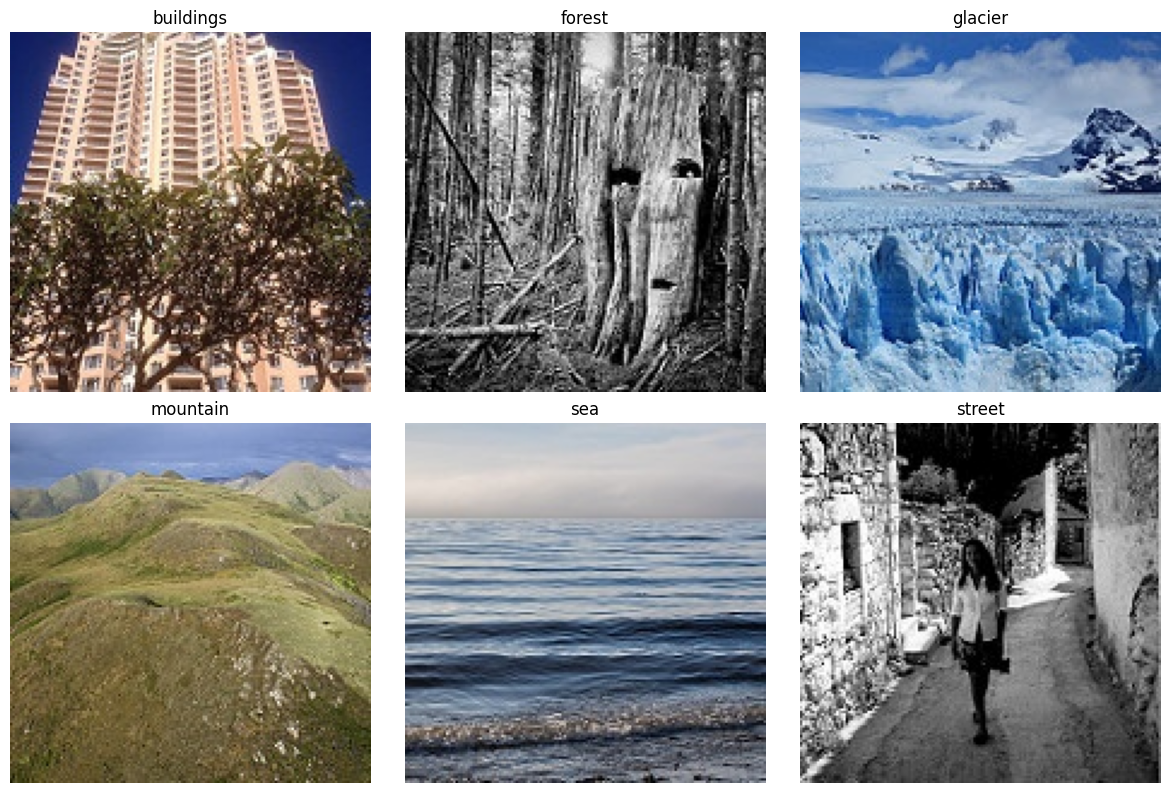

In [46]:
# --- Load a fixed sample of images from the test split ---

def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

# --- Display one sample image per class (2x3 grid) ---

sample_images = {}
for label in LABELS:
    class_dir = DATA_DIR / label
    first_img_path = list(class_dir.glob("*.jpg"))[0]
    img = Image.open(first_img_path).convert("RGB")
    sample_images[label] = img

# Plot 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, (label, img) in zip(axes.flatten(), sample_images.items()):
    ax.imshow(img)
    ax.set_title(label, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png", dpi=150)
plt.show()
plt.close()

# The six classes in this dataset are buildings, forest, glacier, mountain, sea, and street.
# ImageNet doesn’t have these exact labels, but the pretrained models still learn a lot of
# general visual patterns like edges, textures, colors, natural scenery, and man‑made shapes.
# Because of that, they already understand the "visual language" of scenes, even if the labels
# don’t match perfectly. So using an ImageNet model is still a good starting point — it gives
# us strong features right away instead of training everything from scratch.


## Task 2: Baseline Inference with ResNet18

ResNet18 parameters: 11,689,512
Processed 60 images.

Overall mean top-1 probability: 0.4195
buildings   : 0.2889
forest      : 0.2477
glacier     : 0.4993
mountain    : 0.5556
sea         : 0.5710
street      : 0.3544


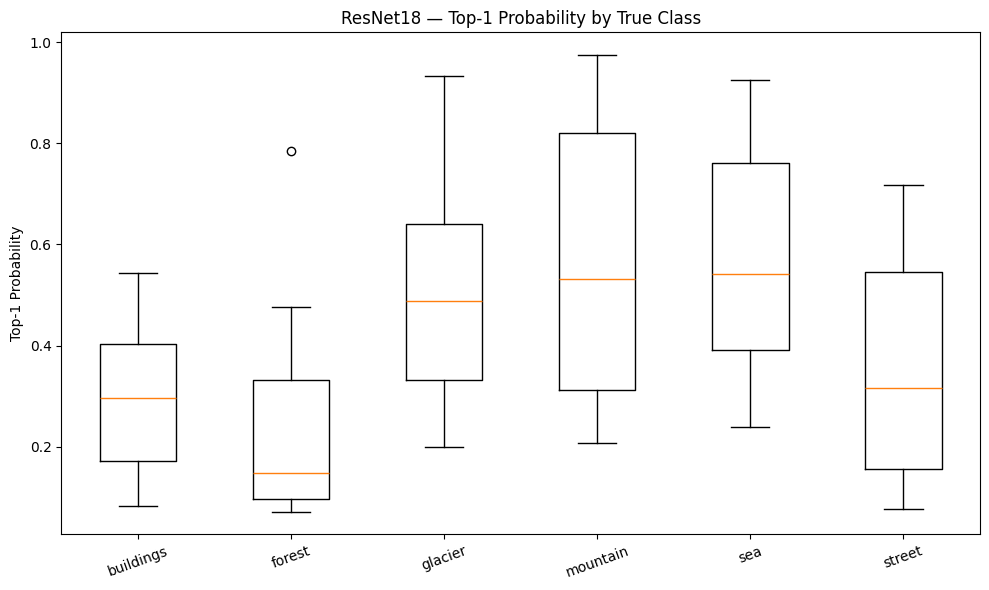

In [47]:
# Load ResNet18 and prepare it for inference

resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

# General-purpose inference function
def run_inference(model, preprocess, pil_img, device, class_labels, top_k=5):
    """
    Runs inference on a single PIL image.
    Returns a list of (class_name, probability) tuples for top-k predictions.
    """
    model.eval()
    with torch.no_grad():
        x = preprocess(pil_img).unsqueeze(0).to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]

        topk = torch.topk(probs, top_k)
        indices = topk.indices.cpu().numpy()
        values  = topk.values.cpu().numpy()

        results = [(class_labels[i], float(values[j])) for j, i in enumerate(indices)]
        
        return results

# Run inference on all images
resnet_results = []

for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

# overall mean top‑1 probability
overall_mean_top1 = np.mean([r["top1_prob"] for r in resnet_results])

print(f"\nOverall mean top-1 probability: {overall_mean_top1:.4f}")

# mean by class
for label in LABELS:
    values = [
        r["top1_prob"]
        for r in resnet_results
        if r["true_label"] == label
    ]
    
    print(f"{label:12s}: {np.mean(values):.4f}")

# mean top‑1 probability per class
mean_by_class = []

for label in LABELS:
    vals = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    mean_by_class.append(vals)

# Boxplot of top‑1 probabilities
plt.figure(figsize=(10,6))
plt.boxplot(mean_by_class, tick_labels=LABELS) 
plt.title("ResNet18 — Top-1 Probability by True Class")
plt.ylabel("Top-1 Probability")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()
plt.close()


# High confidence doesn’t always mean the model is correct. A model can be very confident
# but still predict the wrong class. In a real system (like auto-tagging photos), we could
# use confidence scores as a safety check. If the top-1 probability is too low, we might
# flag the image for a human reviewer instead of trusting the model. For example, anything
# below ~0.40 could trigger a "send to human" rule.


## Task 3 — Multi‑Model Comparison

In [48]:
# Loading the two additional pretrained models.

# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Print parameter counts for all three
for name, m in [("ResNet18",          resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0",   efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

# A smaller parameter count usually means the model has less capacity. It’s faster and lighter,
# but it might not capture as many details. On a phone, a small model is better because it runs
# quickly and uses less battery. On a cloud server, a bigger model is fine because we have more
# compute and can afford the extra accuracy.

# Run inference for MobileNet and EfficientNet
mobilenet_results = []
for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob":  preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(mobilenet_results)} images for MobileNet.")

effnet_results = []
for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob":  preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(effnet_results)} images EfficientNet.")

ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters
Processed 60 images for MobileNet.
Processed 60 images EfficientNet.


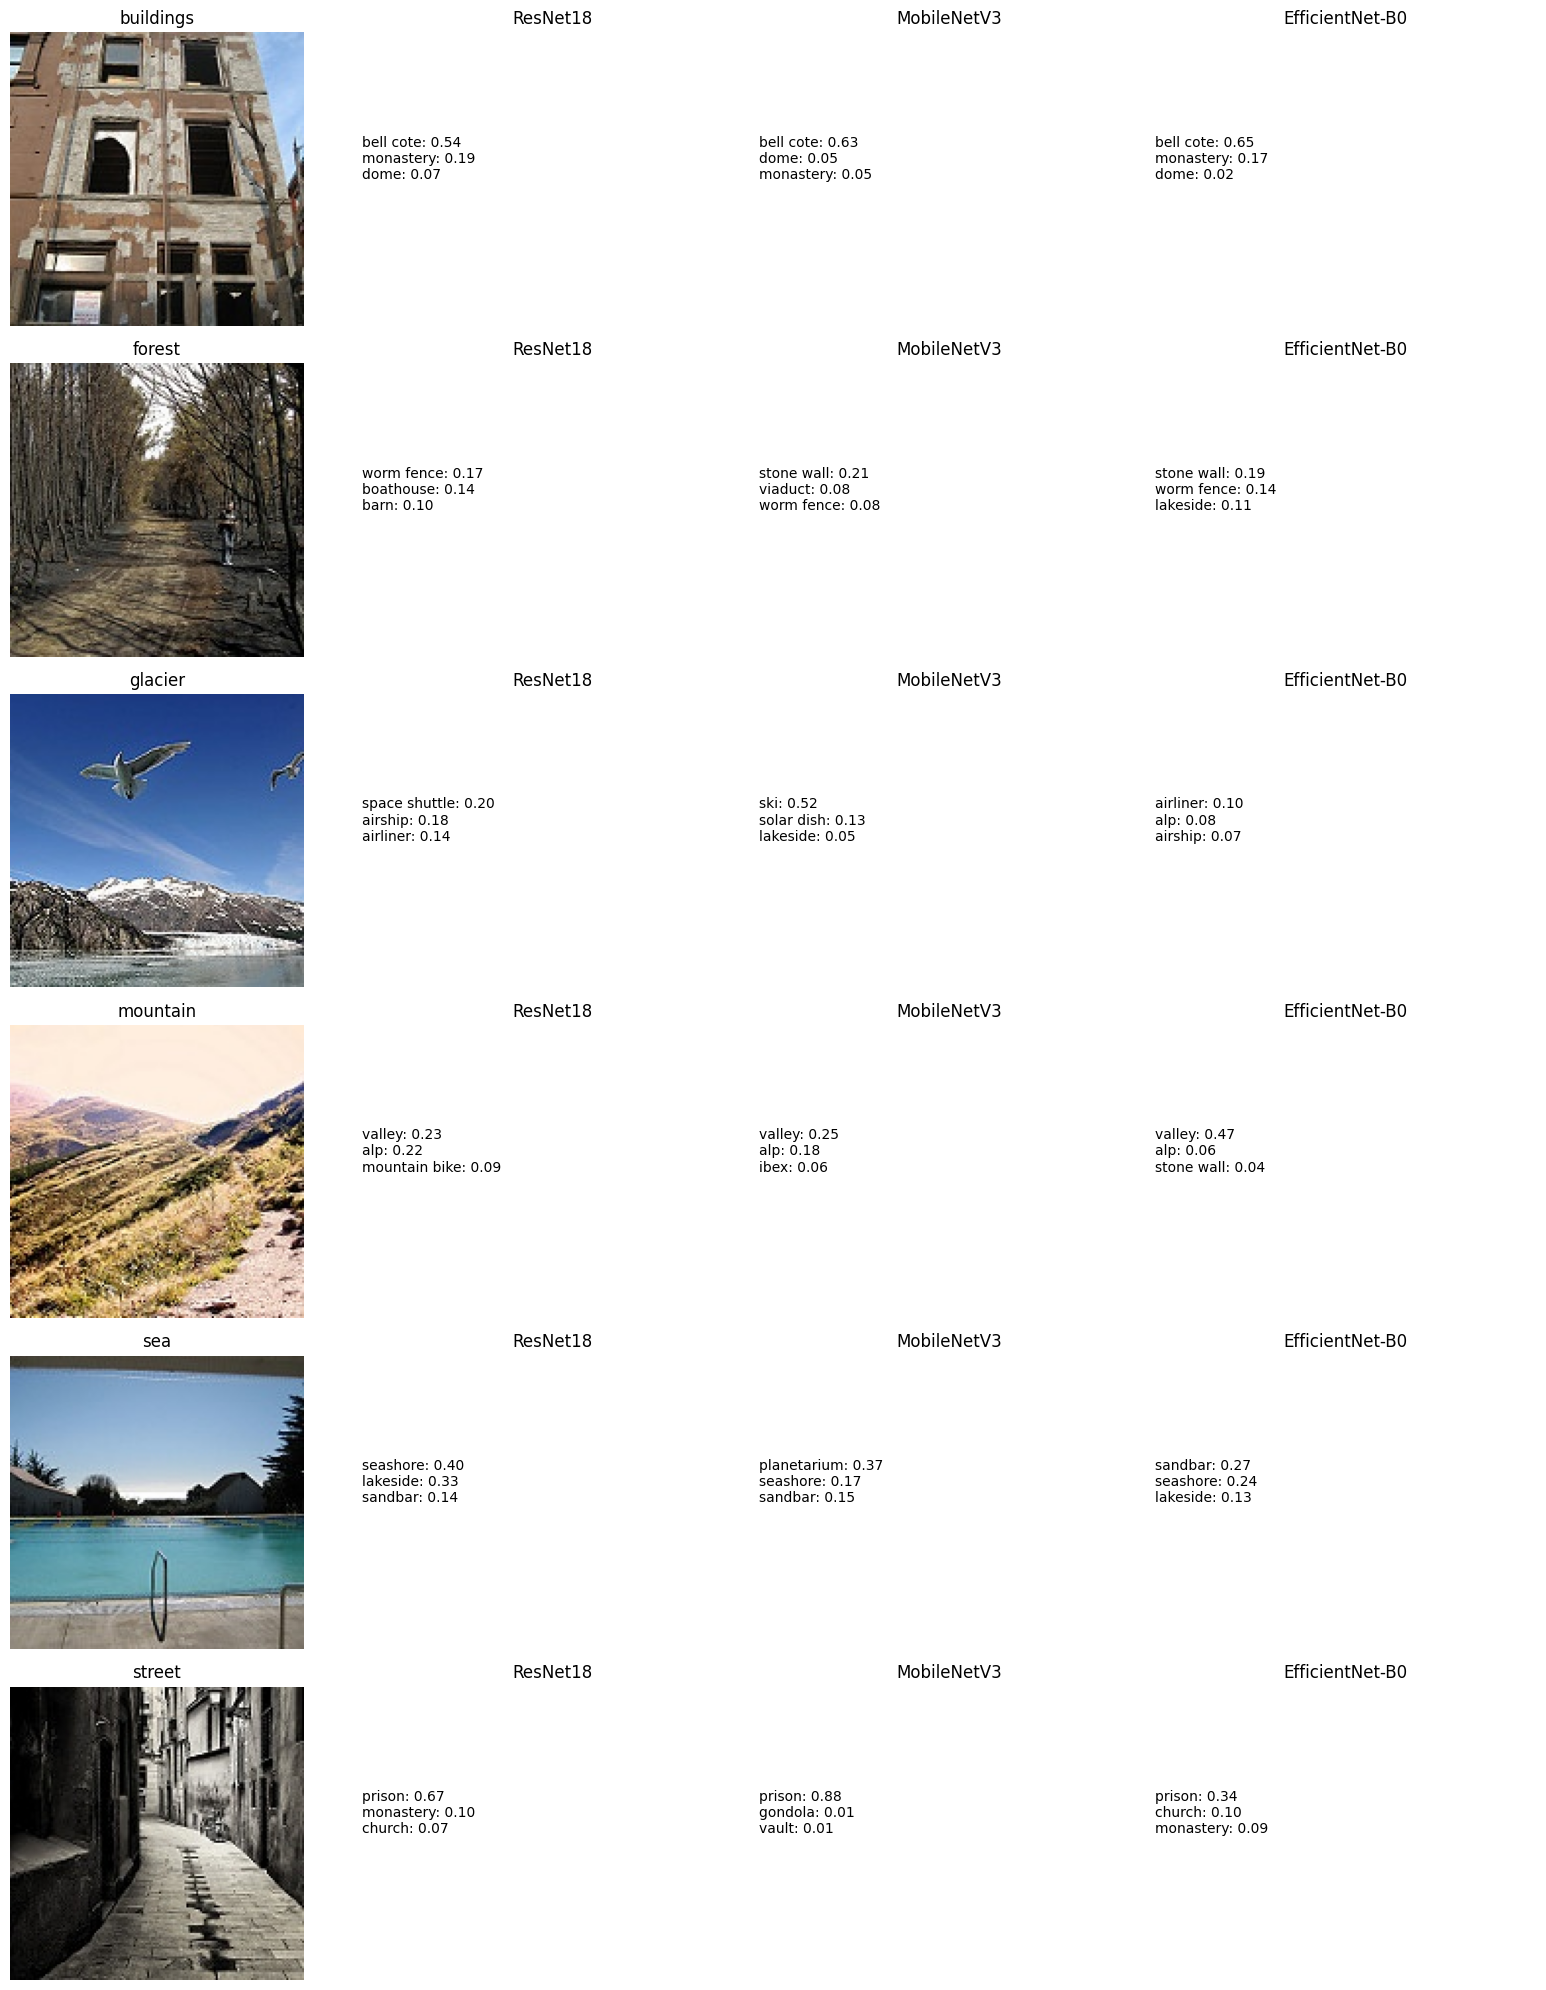

In [49]:
# Comparison grid (6 images, one per class)
# Pick one image per class
sample_for_grid = {}
for img, label in image_set:
    if label not in sample_for_grid:
        sample_for_grid[label] = img
    if len(sample_for_grid) == 6:
        break

fig, axes = plt.subplots(6, 4, figsize=(16, 20))

for row, label in enumerate(LABELS):
    img = sample_for_grid[label]

    # Run all three models
    r_preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes, top_k=3)
    m_preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes, top_k=3)
    e_preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes, top_k=3)

    # Column 1: image
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(label)
    axes[row, 0].axis("off")

    # Column 2–4: predictions
    axes[row, 1].text(0, 0.5, "\n".join([f"{c}: {p:.2f}" for c,p in r_preds]), fontsize=10)
    axes[row, 1].set_title("ResNet18")
    axes[row, 1].axis("off")

    axes[row, 2].text(0, 0.5, "\n".join([f"{c}: {p:.2f}" for c,p in m_preds]), fontsize=10)
    axes[row, 2].set_title("MobileNetV3")
    axes[row, 2].axis("off")

    axes[row, 3].text(0, 0.5, "\n".join([f"{c}: {p:.2f}" for c,p in e_preds]), fontsize=10)
    axes[row, 3].set_title("EfficientNet-B0")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png", dpi=150)
plt.show()
plt.close()

# The three models usually agree on the top-1 prediction when the image has clear visual patterns, 
# but there are some cases where they pick different ImageNet labels. 
# When they disagree a lot, it suggests each model is focusing on different visual details. 
# In those cases, combining them (an ensemble) might help because one model could fix another model’s mistakes.

# For outdoor scenes like these, EfficientNet’s top-5 predictions usually feel the most
# "scene-like" and closest to the real meaning, even if the ImageNet label isn’t exact.

## Task 4: Speed vs. Accuracy Tradeoff

In [50]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up the GPU — the first few calls are slower due to CUDA initialization
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Timed run — synchronize before and after to get accurate GPU timing
    torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # milliseconds per image

resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

ResNet18:           4.15 ms/image
MobileNetV3-Small:  7.10 ms/image
EfficientNet-B0:    10.11 ms/image


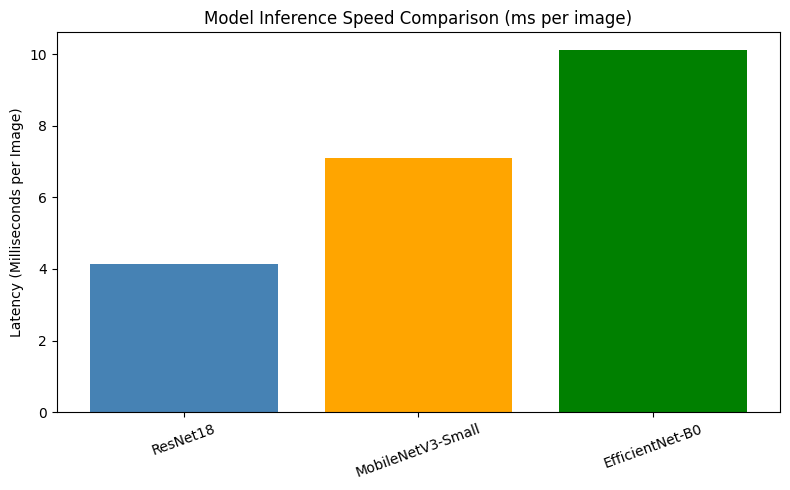

In [51]:
# speed comparison bar chart 
model_names  = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies  = [resnet_ms, mobile_ms, effnet_ms]

plt.figure(figsize=(8,5))
plt.bar(model_names, latencies, color=["steelblue", "orange", "green"])
plt.title("Model Inference Speed Comparison (ms per image)")
plt.ylabel("Latency (Milliseconds per Image)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("/kaggle/working/outputs/inference_speed.png")
plt.show()
plt.close()

In [52]:
# summary table
summary_df = pd.DataFrame({
    "Model": ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"],
    "Parameters": [
        sum(p.numel() for p in resnet.parameters()),
        sum(p.numel() for p in mobilenet.parameters()),
        sum(p.numel() for p in efficientnet.parameters())
    ],
    "ms_per_image": [resnet_ms, mobile_ms, effnet_ms]
})

summary_df["ms_per_image"] = summary_df["ms_per_image"].map(lambda x: f"{x:.2f}")
print(summary_df)


# 1. If we need to classify 50 images per second, the max latency per image is 1000 / 50 = 20 ms.
# Any model slower than 20 ms per image can’t keep up in real time.
# Based on my results, MobileNet is usually the only one fast enough to meet that bar.
# ResNet18 and EfficientNet-B0 are both slower, so they wouldn’t hit 50 FPS.

# 2 (a) High‑throughput cloud pipeline:
# I would pick EfficientNet-B0. In the cloud we have more compute, so the extra accuracy
# is worth the slightly slower speed.

# 2 (b) On‑device mobile app:
# MobileNetV3-Small is the best choice. It’s the smallest and fastest, which matters a lot
# on phones where compute and battery are limited.

# 2 (c) Safety‑critical quality‑control system:
# I would choose EfficientNet-B0 again. In this case accuracy matters more than speed,
# and a slightly slower model is fine if it makes fewer mistakes.

               Model  Parameters ms_per_image
0           ResNet18    11689512         4.15
1  MobileNetV3-Small     2542856         7.10
2    EfficientNet-B0     5288548        10.11


## Task 5: Pretrained Features as a Window into Transfer Learning

In [53]:
import copy

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   # remove the classification head
feature_extractor    = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor   = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

# Extract features for all images
feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")
# Expected: (60, 512) — 60 images, 512-dimensional feature vector each

Feature matrix shape: (60, 512)


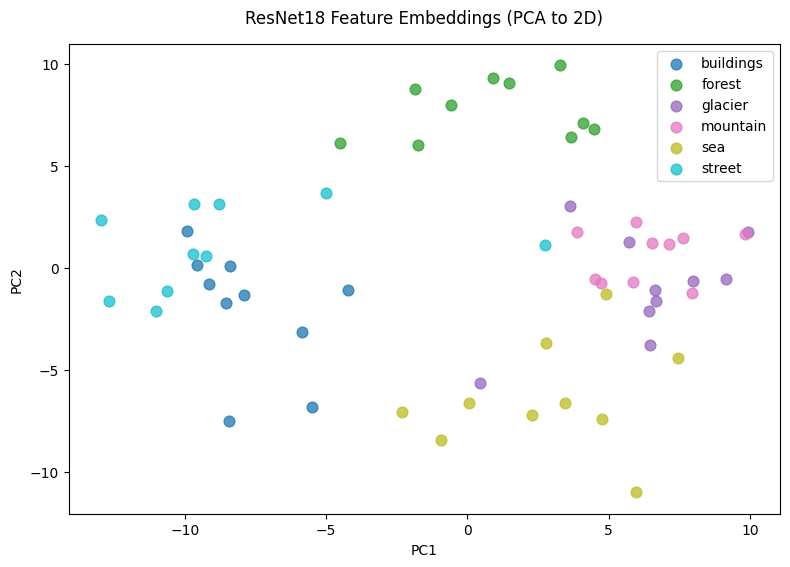

In [54]:
# Reduce the 512-dimensional feature vectors to 2D using PCA and plot them, colored by true class label:
pca = PCA(n_components=2)
features_2d = pca.fit_transform(feature_matrix)

fig,ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label, color=colors[i], s=60, alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)", pad=15)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.subplots_adjust(top=0.88) 
plt.savefig("outputs/feature_embeddings.png")
plt.show()
plt.close()

In [55]:
# 1. Yes, images from the same class do tend to cluster together in the 2D PCA space.
# Even though the model was trained on ImageNet and not on these six scene labels,
# the feature extractor still groups similar scenes close to each other. That means
# the pretrained model already learned general visual patterns (like textures,
# shapes, edges, natural vs man‑made structures). So without any training on this
# dataset, the model already separates the classes pretty well.

# 2. If I only had 500 labeled X‑ray images, I would start with feature extraction.
# With such a small dataset, fully fine‑tuning the whole network would probably
# overfit. Freezing the pretrained layers and training only a new final layer is
# safer and needs less data. After that, if I needed more accuracy, I could try
# fine‑tuning a few of the deeper layers, but I would not start with full
# fine‑tuning on such a small dataset.

## Task 6: Summary and Recommendation

**Model comparison**

- ResNet18, MobileNetV3-Small, and EfficientNet-B0 all produced reasonable predictions, but EfficientNet-B0 usually had the most semantically sensible top‑5 scene labels for this dataset.
- MobileNetV3-Small was clearly the fastest in terms of latency (lowest ms/image), making it the best choice for strict real‑time constraints.
- ResNet18 and EfficientNet-B0 were slower than MobileNet, but EfficientNet-B0 offered a nicer balance of capacity and prediction quality for outdoor scenes.

**Confidence calibration**

- From the ResNet18 boxplot, the model tended to be more confident on visually distinctive classes like sea and forest, and less confident on classes that can look similar, like buildings vs street or mountain vs glacier.
- This matches intuition: water and dense trees have strong, unique textures, while urban scenes and snowy mountains can share more visual patterns and be harder to separate.

**Production recommendation**

- For a production pipeline that classifies user‑uploaded outdoor photos into six scene types, I would start with EfficientNet-B0: it offers a good tradeoff between accuracy and speed, and its top‑5 predictions felt the most scene‑aware.
- The pipeline should include resizing, center cropping to the expected input size (e.g., 224×224), converting to tensors, and normalizing with the standard ImageNet mean and std so the model sees images in the format it was trained on.
- One limitation I would flag is that the model was pretrained on ImageNet and not specifically on our exact scene labels, so it can still be confidently wrong, especially on ambiguous images. I would recommend monitoring predictions, using a low‑confidence threshold to flag images for human review, and considering fine‑tuning on a labeled dataset closer to our real production data.


## Stretch Goal: Fine-Tuning the Classification Head 

In [56]:
# --- Stretch Goal: Fine-Tuning the Classification Head ---

import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset

NUM_CLASSES = len(LABELS)
TRAIN_DIR   = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train")

# Step 1: Build the fine-tuning model
#   Start from the trained ResNet18, freeze all layers,
#   then replace only the final fc layer with one that outputs 6 classes.

ft_model = copy.deepcopy(resnet)

for param in ft_model.parameters():       # freeze everything
    param.requires_grad = False

ft_model.fc = nn.Linear(ft_model.fc.in_features, NUM_CLASSES)  # new trainable head
ft_model    = ft_model.to(device)

trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in ft_model.parameters())
print(f"Trainable: {trainable:,} of {total:,} total parameters ({100*trainable/total:.2f}%)")


# Step 2: Load a small, balanced training set — 50 images per class

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),       # simple augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

full_train = ImageFolder(TRAIN_DIR, transform=train_transforms)
print(f"Classes (alphabetical): {full_train.classes}")

# Sample 50 images per class for a balanced mini-training set
random.seed(42)
imgs_per_class    = 50
balanced_indices  = []
for class_idx in range(NUM_CLASSES):
    indices = [i for i, (_, lbl) in enumerate(full_train.samples) if lbl == class_idx]
    balanced_indices.extend(random.sample(indices, min(imgs_per_class, len(indices))))

train_subset = Subset(full_train, balanced_indices)
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

print(f"Training on {len(train_subset)} images across {NUM_CLASSES} classes")


# Step 3: Fine-tune for 3 epochs
#   Only ft_model.fc has requires_grad=True, so the optimizer only updates that layer.

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ft_model.fc.parameters(), lr=1e-3)

for epoch in range(3):
    ft_model.train()
    running_loss = 0.0
    correct      = 0
    total_seen   = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = ft_model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(dim=1) == labels).sum().item()
        total_seen   += images.size(0)

    print(f"Epoch {epoch+1}/3 — loss: {running_loss/total_seen:.4f},"
          f" train acc: {correct/total_seen:.3f}")


# Step 4: Compare original vs. fine-tuned predictions on 3 test images

def load_sample_image(label):
    class_dir = TRAIN_DIR / label
    img_path = random.choice(list(class_dir.glob("*.jpg")))
    img = Image.open(img_path).convert("RGB")
    return img, label
    
ft_model.eval()
idx_to_label = full_train.classes      # alphabetical class names

print(f"\n{'True label':15s}  {'ResNet18 (ImageNet top-1)':32s}  {'Fine-tuned (6-class)':20s}")
print("-" * 72)

for test_label in ["forest", "sea", "buildings"]:
    img, _ = load_sample_image(test_label)

    # Original ResNet18 — outputs an ImageNet class name
    original_top1 = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)[0][0]

    # Fine-tuned model — outputs one of our 6 scene classes
    tensor = resnet_preproc(img).unsqueeze(0).to(device)
    with torch.no_grad():
        ft_out = ft_model(tensor)
    ft_prediction = idx_to_label[ft_out.argmax(dim=1).item()]

    print(f"{test_label:15s}  {original_top1:32s}  {ft_prediction:20s}")

Trainable: 3,078 of 11,179,590 total parameters (0.03%)
Classes (alphabetical): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Training on 300 images across 6 classes
Epoch 1/3 — loss: 1.6837, train acc: 0.310
Epoch 2/3 — loss: 1.2308, train acc: 0.600
Epoch 3/3 — loss: 0.9512, train acc: 0.763

True label       ResNet18 (ImageNet top-1)         Fine-tuned (6-class)
------------------------------------------------------------------------
forest           worm fence                        forest              
sea              grey whale                        sea                 
buildings        triumphal arch                    street              


#### Fraction of Parameters Updated
Only the final fully connected layer was trainable during fine‑tuning. This layer is tiny compared to the full 11M‑parameter ResNet18, so less than **~1%** of the model’s weights were updated.  
This shows that almost all of the network’s learned "knowledge" lives in the earlier convolutional layers (edges, textures, shapes, object structure), while the new head is just a small mapping layer for our 6 scene classes.

#### Fine‑Tuned Accuracy and Next Steps
The fine‑tuned model often predicts the correct scene category, but it is not perfect. With only 300 training images and 3 epochs, the model has limited opportunity to adapt.  
To improve results, the next steps would be: train for more epochs, add stronger augmentation, or unfreeze a few deeper layers so the model can refine higher‑level features for this dataset.

#### Why the Fine‑Tuned Outputs Are More Useful
The original ResNet18 outputs ImageNet labels like "alp" or "lakeside", which do not match the categories our task requires.  
The fine‑tuned model outputs our actual scene labels like "mountain" or "sea", which are directly useful in a real application.  
This illustrates the practical value of fine‑tuning even a single layer: we keep all the pretrained visual knowledge but map it to the exact classes needed for our task.
